<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Forecasting_time_series_data_freecodecamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install statsforecast utilsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


### Import libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

###Initial Setup

In [13]:
df = pd.read_csv("/content/sample_data/daily_sales_french_bakery.csv", parse_dates=["ds"])
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


In [14]:
df.shape

(57046, 4)

In [11]:
df.describe()

,ds,y
count,56904,56904.000000
mean,2021-11-18 15:23:18.397300480,9.796240
min,2021-01-02 00:00:00,0.000000
25%,2021-06-25 00:00:00,0.000000
50%,2021-11-17 00:00:00,0.900000
75%,2022-04-17 00:00:00,8.000000
max,2022-09-30 00:00:00,919.100000
std,NaN,32.357288


In [22]:
df["unique_id"].value_counts()

,count
unique_id,
BAGUETTE,637
BOULE 400G,637
BANETTE,637
BOULE 200G,637
BANETTINE,637
...,...
RELIGIEUSE,71
SABLE F P,68
DELICETROPICAL,63


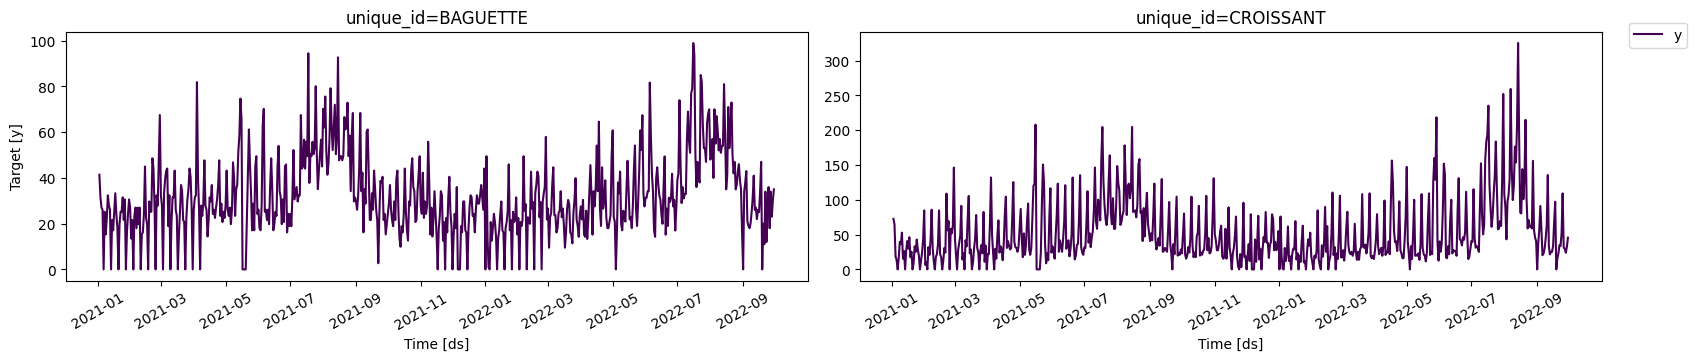

In [23]:
plot_series(df = df, ids = ["BAGUETTE","CROISSANT"], palette="viridis")

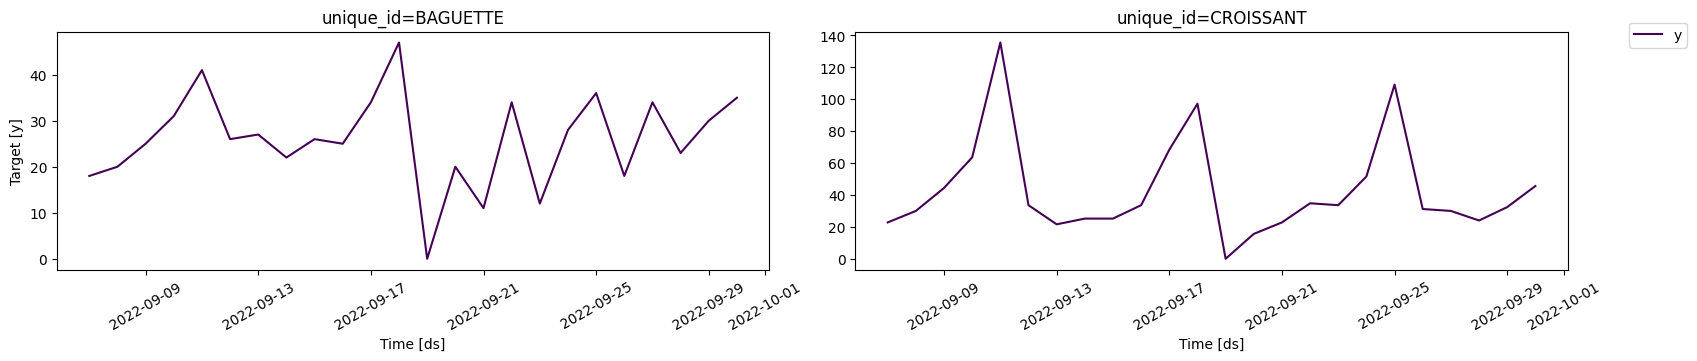

In [25]:
plot_series(df = df, ids = ["BAGUETTE","CROISSANT"],max_insample_length= 24, palette="viridis")

###Baseline Model

In [26]:
from statsforecast import StatsForecast
from statsforecast.models import Naive,HistoricAverage,WindowAverage,SeasonalNaive

In [28]:
horizon = 7 #We have daily dataset, nice to forecast nextweek data, so 7

models = [
    Naive(), # simply forecast the last time known timestep
    HistoricAverage(), #take the average of the entire history of our series ,the use the value as a forecast
    WindowAverage(window_size= 7),  #how many timesteps do you want to take into account to calculate that average? and forecast that value.
                                    #window_size = 7 means, take average of the last seven days and forecast that into future
    SeasonalNaive(season_length=7),
]

sf = StatsForecast(models = models, freq = "D") #freqency of the data---daily for D
sf.fit(df=df)

preds = sf.predict(h = horizon)

In [29]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


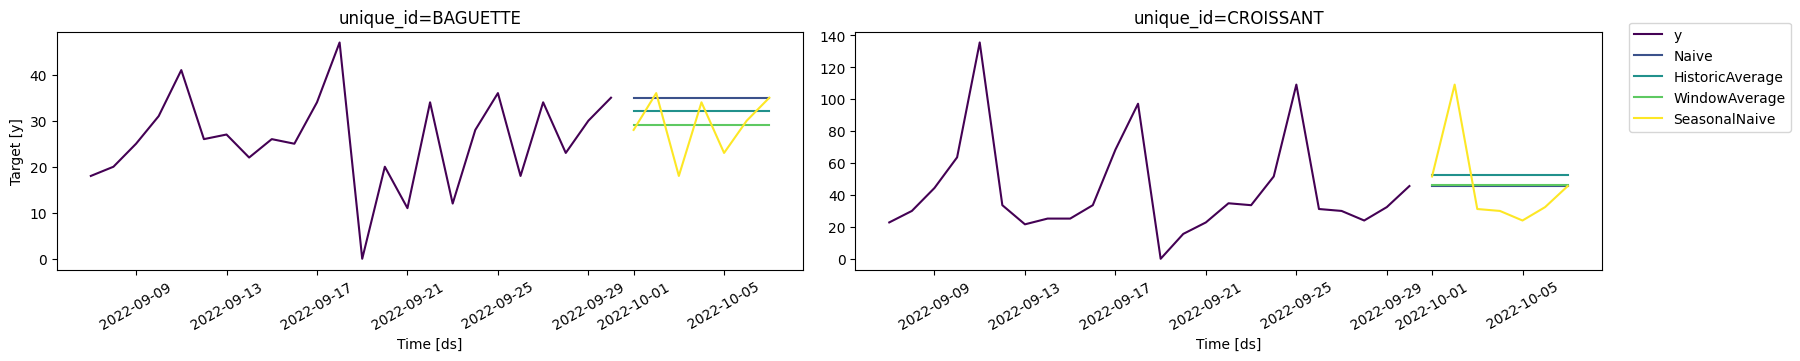

In [40]:
plot_series(
    df =df,
    forecasts_df= preds,
    ids = ["BAGUETTE","CROISSANT"],
    max_insample_length= 24,
    palette = "viridis"
)

###Evaluate baseline models

In [41]:
test = df.groupby("unique_id").tail(17)
train = df.drop(test.index).reset_index(drop = True)

In [42]:
sf.fit(df = train)
preds = sf.predict(h = horizon)
eval_df = pd.merge(test, preds,'left', ['ds', 'unique_id'])

In [44]:
evaluation = evaluate(
    eval_df,
    metrics= [mae],

)
evaluation.head(10)

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,8.571429,9.555035,5.510204,4.285714
1,BAGUETTE,mae,9.857143,12.142673,9.795918,7.428571
2,BAGUETTE APERO,mae,0.000000,0.539293,0.000000,0.000000
3,BAGUETTE GRAINE,mae,1.200000,4.035272,1.914286,0.200000
4,BANETTE,mae,12.157143,14.073329,9.739796,11.664286
5,BANETTINE,mae,1.500000,1.163295,1.157143,1.300000
6,BOISSON 33CL,mae,3.214286,3.816574,3.153061,3.642857
7,BOULE 200G,mae,3.257143,3.163502,3.306122,2.914286
8,BOULE 400G,mae,8.257143,4.140184,4.753061,6.557143
9,BOULE POLKA,mae,1.285714,0.694562,1.065306,0.771429


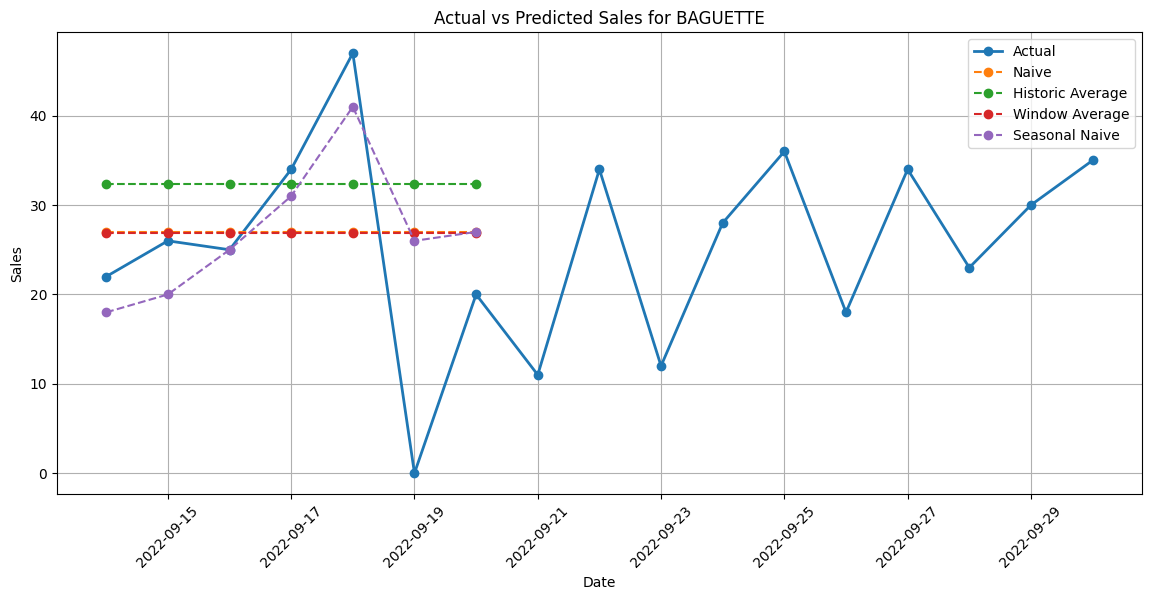

In [48]:

# Selecting one product
product_name = "BAGUETTE"

plot_df = eval_df[eval_df["unique_id"] == product_name].copy()

# Keeping only the 17 test rows
plot_df = plot_df.sort_values("ds").tail(17)

plt.figure(figsize=(14, 6))

# Actual values
plt.plot(
    plot_df["ds"],
    plot_df["y"],
    marker="o",
    linewidth=2,
    label="Actual"
)

# Model predictions
plt.plot(
    plot_df["ds"],
    plot_df["Naive"],
    marker="o",
    linestyle="--",
    label="Naive"
)

plt.plot(
    plot_df["ds"],
    plot_df["HistoricAverage"],
    marker="o",
    linestyle="--",
    label="Historic Average"
)

plt.plot(
    plot_df["ds"],
    plot_df["WindowAverage"],
    marker="o",
    linestyle="--",
    label="Window Average"
)

plt.plot(
    plot_df["ds"],
    plot_df["SeasonalNaive"],
    marker="o",
    linestyle="--",
    label="Seasonal Naive"
)

plt.title(f"Actual vs Predicted Sales for {product_name}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [45]:
evaluation = evaluation.drop(['unique_id'],axis = 1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,5.009563,5.55806,5.279111,4.439256


/tmp/ipykernel_2774/1213420645.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='MAE', data=plot_data, palette='viridis')


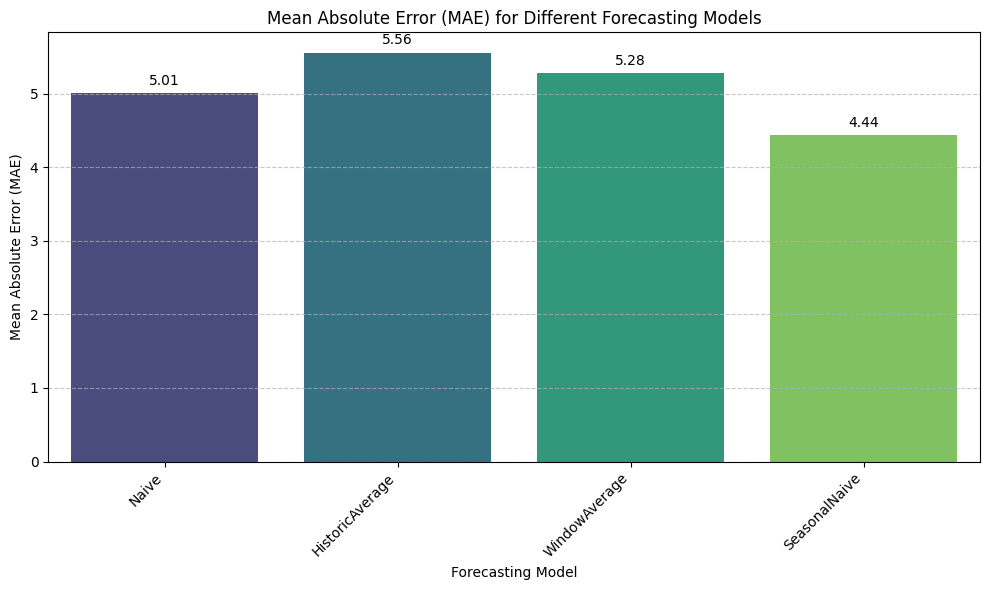

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for plotting
plot_data = evaluation.set_index('metric').stack().reset_index()
plot_data.columns = ['metric', 'Model', 'MAE']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='MAE', data=plot_data, palette='viridis')
plt.title('Mean Absolute Error (MAE) for Different Forecasting Models')
plt.xlabel('Forecasting Model')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()